# Correlation Analysis: Google Trends × Stock Returns

**Matrix 1** — Each Google Trends keyword (row) × each individual NSE ticker (col)  
**Matrix 2** — Each Google Trends keyword (row) × sector-averaged daily return (col)  

Pearson r computed over the ~26 overlapping trading days (Mar 4 – Apr 13 2026).

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

trends  = pd.read_csv('google_trends_raw.xls', index_col=0, parse_dates=True)
trends.index.name = 'date'
returns = pd.read_csv('ohlc_processed.xls', parse_dates=['date'], index_col='date')

print(f"Trends  shape : {trends.shape}  ({trends.index.min().date()} → {trends.index.max().date()})")
print(f"Returns shape : {returns.shape} ({returns.index.min().date()} → {returns.index.max().date()})")

# ── Sector map hardcoded from rawstocksdb.ipynb ticker groupings ──────────────
TICKER_SECTOR = {
    # Oil & Gas — OMCs
    'HINDPETRO.NS': 'Oil & Gas — OMCs',
    'BPCL.NS':      'Oil & Gas — OMCs',
    'IOC.NS':       'Oil & Gas — OMCs',
    'IGL.NS':       'Oil & Gas — OMCs',
    'MGL.NS':       'Oil & Gas — OMCs',
    'GUJARATGAS.NS':'Oil & Gas — OMCs',
    # Oil & Gas — Upstream
    'ONGC.NS':      'Oil & Gas — Upstream',
    'OIL.NS':       'Oil & Gas — Upstream',
    'VEDL.NS':      'Oil & Gas — Upstream',
    # Defence
    'HAL.NS':       'Defence',
    'BDL.NS':       'Defence',
    'BEL.NS':       'Defence',
    'BEML.NS':      'Defence',
    'MAZDOCK.NS':   'Defence',
    'GRSE.NS':      'Defence',
    'COCHINSHIP.NS':'Defence',
    'DATAPATTNS.NS':'Defence',
    # Aviation
    'INDIGO.NS':    'Aviation',
    # Paints
    'ASIANPAINT.NS':'Paints',
    'BERGEPAINT.NS':'Paints',
    'KANSAINER.NS': 'Paints',
    'INDIGOPNTS.NS':'Paints',
    # Tyres
    'MRF.NS':       'Tyres',
    'APOLLOTYRE.NS':'Tyres',
    'CEATLTD.NS':   'Tyres',
    'BALKRISIND.NS':'Tyres',
    # Pharma
    'SUNPHARMA.NS': 'Pharma',
    'DRREDDY.NS':   'Pharma',
    'DIVISLAB.NS':  'Pharma',
    'CIPLA.NS':     'Pharma',
    # Shipping & Ports
    'ADANIPORTS.NS':'Shipping & Ports',
    'SCI.NS':       'Shipping & Ports',
    'GESHIP.NS':    'Shipping & Ports',
    'ESSARSHPNG.NS':'Shipping & Ports',
    # Capital Goods
    'LT.NS':        'Capital Goods',
    'THERMAX.NS':   'Capital Goods',
    'KEC.NS':       'Capital Goods',
    # Gold-Linked
    'TITAN.NS':     'Gold-Linked',
    'KALYANKJIL.NS':'Gold-Linked',
    'MUTHOOTFIN.NS':'Gold-Linked',
    'MANAPPURAM.NS':'Gold-Linked',
    # Chemicals & Fertilisers
    'COROMANDEL.NS':'Chemicals & Fertilisers',
    'DEEPAKNTR.NS': 'Chemicals & Fertilisers',
    'GNFC.NS':      'Chemicals & Fertilisers',
    'TATACHEM.NS':  'Chemicals & Fertilisers',
    # IT & Tech
    'INFY.NS':      'IT & Tech',
    'WIPRO.NS':     'IT & Tech',
    'HCLTECH.NS':   'IT & Tech',
}

meta = (
    pd.DataFrame(list(TICKER_SECTOR.items()), columns=['ticker', 'sector'])
    .set_index('ticker')
)

# ── Align on trading days present in both datasets ────────────────────────────
common = trends.index.intersection(returns.index)
T = trends.loc[common]
R = returns.loc[common]

print(f"\nOverlapping trading days : {len(common)}")
print(f"Keywords                 : {T.shape[1]}")
print(f"Tickers in returns       : {R.shape[1]}")
print(f"Tickers with sector map  : {sum(1 for t in R.columns if t in TICKER_SECTOR)}")

Trends  shape : (47, 60)  (2026-02-28 → 2026-04-15)
Returns shape : (26, 47) (2026-03-04 → 2026-04-13)

Overlapping trading days : 26
Keywords                 : 60
Tickers in returns       : 47
Tickers with sector map  : 47


In [3]:
# ── Keyword order: all 60 keywords grouped by original query section ──────────
KW_GROUPS_ORDERED = [
    # Geopolitical / War
    ['iran israel war', 'strait of hormuz', 'middle east war', 'world war 3',
     'iran attack', 'israel bombing', 'us iran war', 'hormuz blockade',
     'oil tanker attack', 'middle east conflict'],
    # Oil & Energy
    ['oil prices', 'crude oil price', 'brent crude', 'petrol price india',
     'fuel price india', 'oil supply shortage', 'opec oil cut', 'energy crisis',
     'oil price rise', 'diesel price india'],
    # Indian Market Panic
    ['nifty crash', 'sensex crash', 'nifty fall today', 'stock market crash india',
     'sensex today', 'nifty today', 'should i sell stocks', 'stock market india',
     'nifty prediction', 'market circuit breaker'],
    # Macro / Economy Fear
    ['inflation india', 'recession 2026', 'dollar rupee', 'rupee fall',
     'india gdp', 'rbi rate hike', 'india economy war', 'war inflation',
     'global recession', 'import export india'],
    # Sector Specific
    ['aviation fuel price', 'indigo airlines', 'spicejet shares', 'ongc share price',
     'reliance share price', 'defence stocks india', 'hal share price',
     'shipping stocks india', 'gold price india', 'gold rate today'],
    # Retail Investor Behaviour
    ['buy gold now', 'safe investment india', 'best stocks to buy now',
     'where to invest during war', 'mutual fund safe', 'fd vs stocks',
     'sell stocks now', 'war proof investment', 'dollar buy india', 'sovereign gold bond'],
]

KW_ORDER = []
for grp in KW_GROUPS_ORDERED:
    KW_ORDER += [k for k in grp if k in T.columns]

kw_group_sizes = [sum(1 for k in grp if k in T.columns) for grp in KW_GROUPS_ORDERED]
kw_boundaries  = list(np.cumsum(kw_group_sizes)[:-1])

print(f"Total keywords in KW_ORDER : {len(KW_ORDER)}")
print(f"Group sizes                : {kw_group_sizes}")

# ── Ticker order: grouped by sector ───────────────────────────────────────────
SECTOR_ORDER = [
    'Oil & Gas — OMCs',
    'Oil & Gas — Upstream',
    'Aviation',
    'Shipping & Ports',
    'Defence',
    'Capital Goods',
    'Gold-Linked',
    'Chemicals & Fertilisers',
    'Tyres',
    'Paints',
    'Pharma',
    'IT & Tech',
]

ticker_order = []
for sec in SECTOR_ORDER:
    tickers_in_sec = meta[meta['sector'] == sec].index.tolist()
    ticker_order += [t for t in tickers_in_sec if t in R.columns]

# ── Compute correlation matrix 1: Keywords × Tickers ─────────────────────────
combined1 = pd.concat([T[KW_ORDER], R[ticker_order]], axis=1)
full_corr1 = combined1.corr()
CORR1 = full_corr1.loc[KW_ORDER, ticker_order]

print(f"Matrix 1 shape : {CORR1.shape}")
print(f"Value range    : {CORR1.min().min():.3f}  →  {CORR1.max().max():.3f}")

Total keywords in KW_ORDER : 60
Group sizes                : [10, 10, 10, 10, 10, 10]
Matrix 1 shape : (60, 47)
Value range    : -0.744  →  0.435


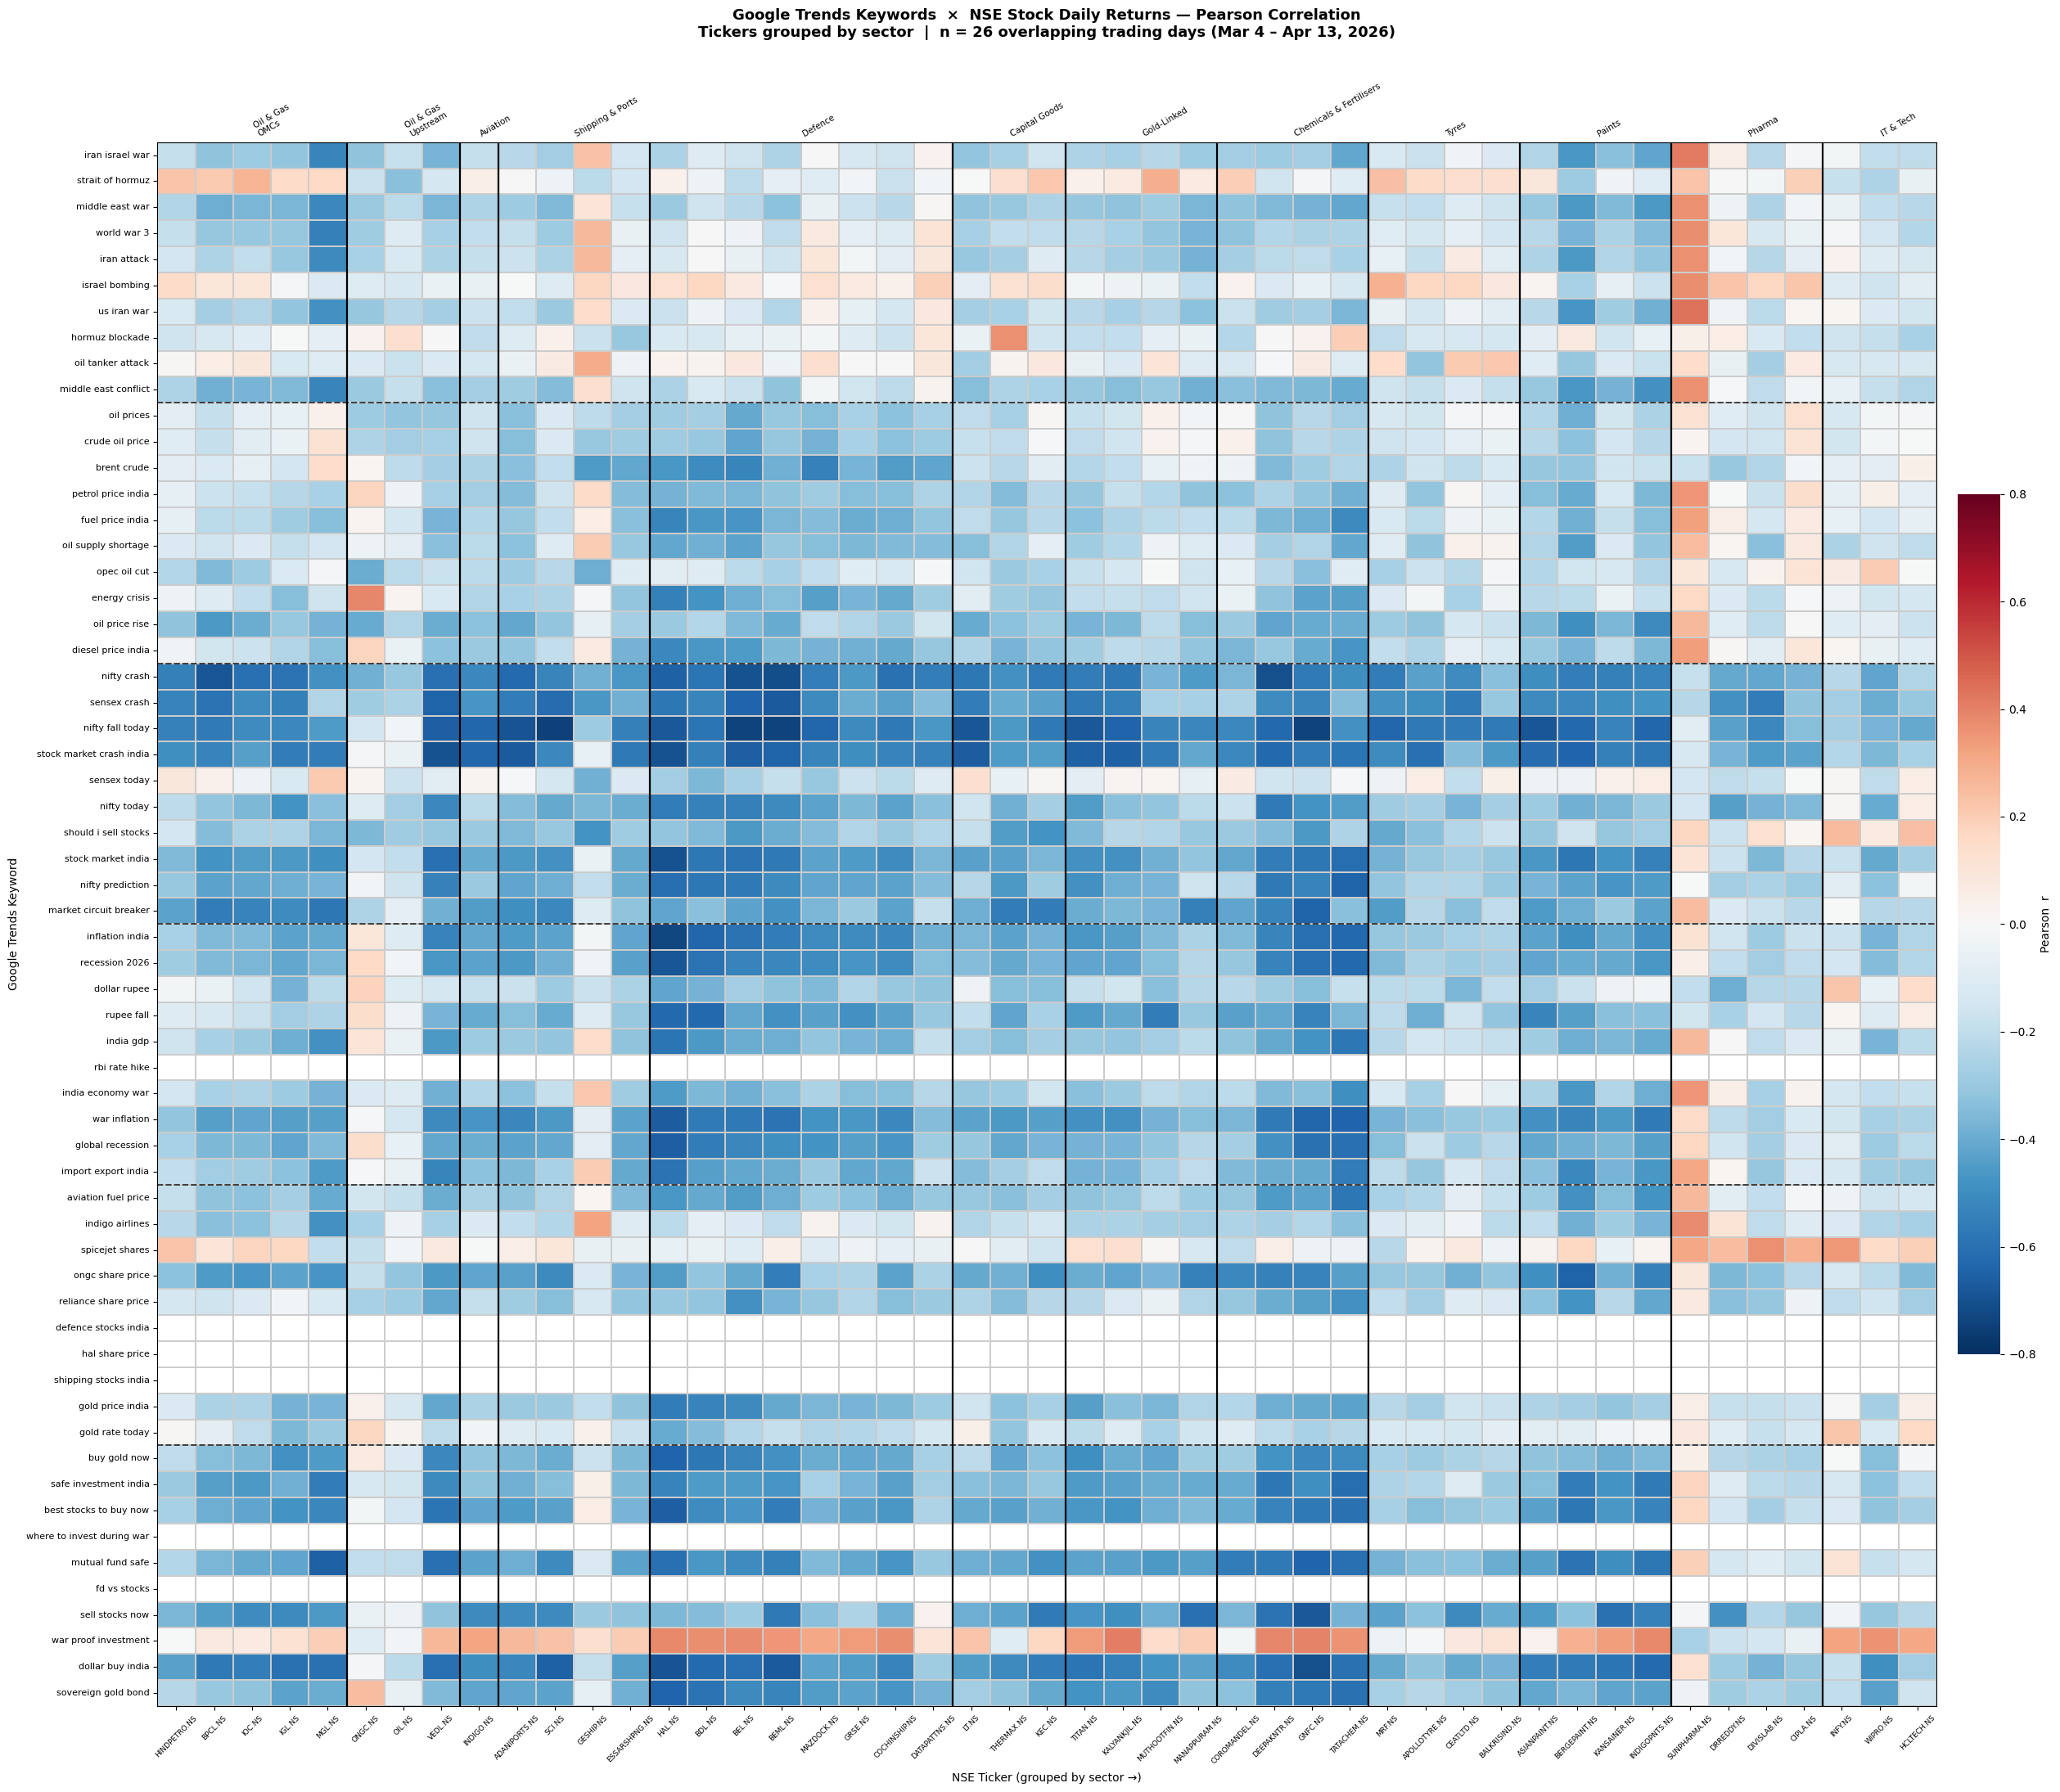

Saved: corr_keywords_tickers.png


In [4]:
# ── Heatmap 1: Keywords × Individual Tickers ──────────────────────────────────

# Sector boundary positions for divider lines
sector_counts = []
for sec in SECTOR_ORDER:
    count = sum(1 for t in ticker_order if meta.loc[t, 'sector'] == sec)
    sector_counts.append(count)
boundaries = list(np.cumsum(sector_counts)[:-1])

# Sector label midpoints (for x-axis sector annotations)
midpoints = []
pos = 0
for cnt in sector_counts:
    midpoints.append(pos + cnt / 2)
    pos += cnt

# kw_group_sizes and kw_boundaries are computed dynamically in the previous cell

fig, ax = plt.subplots(figsize=(28, 22))

sns.heatmap(
    CORR1,
    cmap='RdBu_r',
    center=0,
    vmin=-0.8, vmax=0.8,
    linewidths=0.15,
    linecolor='#cccccc',
    annot=False,
    ax=ax,
    cbar_kws={'label': 'Pearson  r', 'shrink': 0.55, 'pad': 0.01},
)

# Sector divider lines (vertical)
for b in boundaries:
    ax.axvline(b, color='black', linewidth=1.6)

# Keyword theme divider lines (horizontal)
for b in kw_boundaries:
    ax.axhline(b, color='black', linewidth=1.4, linestyle='--', alpha=0.7)

# Sector labels above heatmap
ax2 = ax.twiny()
ax2.set_xlim(ax.get_xlim())
ax2.set_xticks(midpoints)
ax2.set_xticklabels(
    [s.replace(' — ', '\n') for s in SECTOR_ORDER],
    fontsize=7.5, rotation=30, ha='left'
)
ax2.tick_params(length=0)

ax.set_title(
    'Google Trends Keywords  ×  NSE Stock Daily Returns — Pearson Correlation\n'
    'Tickers grouped by sector  |  n = 26 overlapping trading days (Mar 4 – Apr 13, 2026)',
    fontsize=13, pad=40, fontweight='bold'
)
ax.set_xlabel('NSE Ticker (grouped by sector →)', fontsize=10, labelpad=6)
ax.set_ylabel('Google Trends Keyword', fontsize=10, labelpad=6)
ax.tick_params(axis='x', labelsize=6.5, rotation=45)
ax.tick_params(axis='y', labelsize=8,   rotation=0)

plt.tight_layout()
plt.savefig('corr_keywords_tickers.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: corr_keywords_tickers.png")

In [5]:
# ── Compute sector-average returns ────────────────────────────────────────────
sector_ret = {}
for sec in SECTOR_ORDER:
    tickers_in_sec = meta[meta['sector'] == sec].index.tolist()
    available = [t for t in tickers_in_sec if t in R.columns]
    if available:
        sector_ret[sec] = R[available].mean(axis=1)

S = pd.DataFrame(sector_ret).loc[common]  # rows = trading days, cols = sectors

print("Sector average daily returns:")
print(f"Shape: {S.shape}")
print(f"\nSectors with ticker counts:")
for sec in SECTOR_ORDER:
    tickers_in_sec = meta[meta['sector'] == sec].index.tolist()
    available = [t for t in tickers_in_sec if t in R.columns]
    if available:
        print(f"  {sec:<30s} — {len(available)} tickers")

# ── Compute correlation matrix 2: Keywords × Sectors ─────────────────────────
combined2 = pd.concat([T[KW_ORDER], S], axis=1)
full_corr2 = combined2.corr()
CORR2 = full_corr2.loc[KW_ORDER, list(sector_ret.keys())]

print(f"\nMatrix 2 shape : {CORR2.shape}")
print(f"Value range    : {CORR2.min().min():.3f}  →  {CORR2.max().max():.3f}")

Sector average daily returns:
Shape: (26, 12)

Sectors with ticker counts:
  Oil & Gas — OMCs               — 5 tickers
  Oil & Gas — Upstream           — 3 tickers
  Aviation                       — 1 tickers
  Shipping & Ports               — 4 tickers
  Defence                        — 8 tickers
  Capital Goods                  — 3 tickers
  Gold-Linked                    — 4 tickers
  Chemicals & Fertilisers        — 4 tickers
  Tyres                          — 4 tickers
  Paints                         — 4 tickers
  Pharma                         — 4 tickers
  IT & Tech                      — 3 tickers

Matrix 2 shape : (60, 12)
Value range    : -0.746  →  0.375


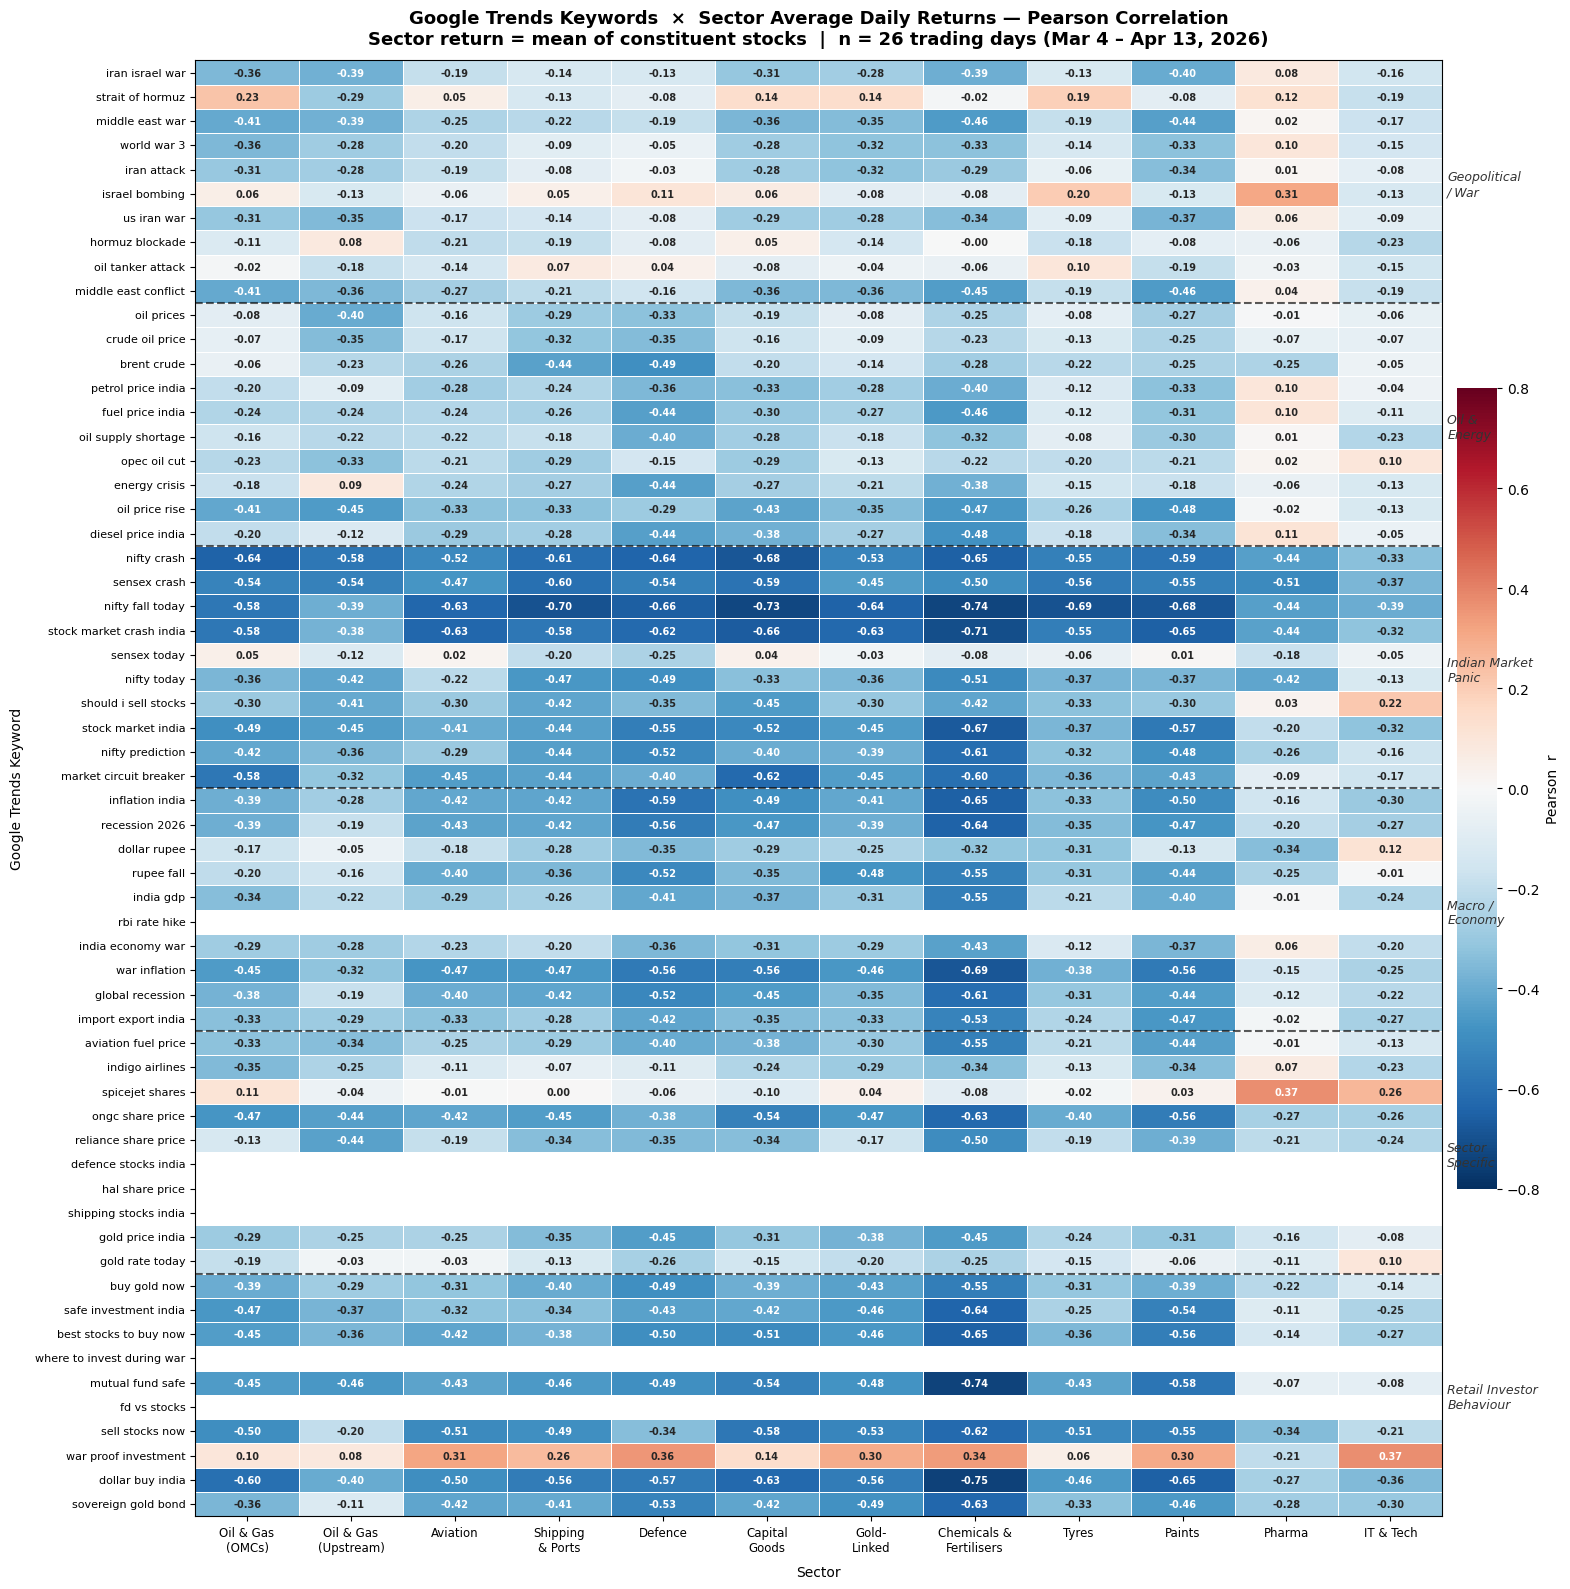

Saved: corr_keywords_sectors.png


In [6]:
# ── Heatmap 2: Keywords × Sectors ─────────────────────────────────────────────

SHORT_SEC = {
    'Oil & Gas — OMCs':          'Oil & Gas\n(OMCs)',
    'Oil & Gas — Upstream':      'Oil & Gas\n(Upstream)',
    'Aviation':                  'Aviation',
    'Shipping & Ports':          'Shipping\n& Ports',
    'Defence':                   'Defence',
    'Capital Goods':             'Capital\nGoods',
    'Gold-Linked':               'Gold-\nLinked',
    'Chemicals & Fertilisers':   'Chemicals &\nFertilisers',
    'Tyres':                     'Tyres',
    'Paints':                    'Paints',
    'Pharma':                    'Pharma',
    'IT & Tech':                 'IT & Tech',
}

CORR2_display = CORR2.copy()
CORR2_display.columns = [SHORT_SEC.get(c, c) for c in CORR2_display.columns]

fig, ax = plt.subplots(figsize=(17, 16))

sns.heatmap(
    CORR2_display,
    cmap='RdBu_r',
    center=0,
    vmin=-0.8, vmax=0.8,
    linewidths=0.6,
    linecolor='white',
    annot=True,
    fmt='.2f',
    annot_kws={'size': 7, 'weight': 'bold'},
    ax=ax,
    cbar_kws={'label': 'Pearson  r', 'shrink': 0.55, 'pad': 0.01},
)

# Keyword theme divider lines
for b in kw_boundaries:
    ax.axhline(b, color='black', linewidth=1.5, linestyle='--', alpha=0.65)

# Theme labels on right y-axis (one per group)
theme_labels = [
    'Geopolitical\n/ War',
    'Oil &\nEnergy',
    'Indian Market\nPanic',
    'Macro /\nEconomy',
    'Sector\nSpecific',
    'Retail Investor\nBehaviour',
]
theme_mids = [sum(kw_group_sizes[:i]) + kw_group_sizes[i] / 2 for i in range(len(kw_group_sizes))]

ax3 = ax.twinx()
ax3.set_ylim(ax.get_ylim())
ax3.set_yticks(theme_mids)
ax3.set_yticklabels(theme_labels, fontsize=9, color='#333333', fontstyle='italic')
ax3.tick_params(length=0)

ax.set_title(
    'Google Trends Keywords  ×  Sector Average Daily Returns — Pearson Correlation\n'
    'Sector return = mean of constituent stocks  |  n = 26 trading days (Mar 4 – Apr 13, 2026)',
    fontsize=13, pad=12, fontweight='bold'
)
ax.set_xlabel('Sector', fontsize=10, labelpad=8)
ax.set_ylabel('Google Trends Keyword', fontsize=10, labelpad=8)
ax.tick_params(axis='x', labelsize=8.5, rotation=0)
ax.tick_params(axis='y', labelsize=8,   rotation=0)

plt.tight_layout()
plt.savefig('corr_keywords_sectors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: corr_keywords_sectors.png")

In [7]:
# ── Top correlations summary ───────────────────────────────────────────────────
print("=" * 60)
print("TOP 15 POSITIVE CORRELATIONS (keyword → sector)")
print("=" * 60)
stack2 = CORR2.stack().rename('r').reset_index()
stack2.columns = ['keyword', 'sector', 'r']
top_pos = stack2.nlargest(15, 'r')
for _, row in top_pos.iterrows():
    print(f"  {row['r']:+.3f}  |  {row['keyword']:<30s}  →  {row['sector']}")

print()
print("=" * 60)
print("TOP 15 NEGATIVE CORRELATIONS (keyword → sector)")
print("=" * 60)
top_neg = stack2.nsmallest(15, 'r')
for _, row in top_neg.iterrows():
    print(f"  {row['r']:+.3f}  |  {row['keyword']:<30s}  →  {row['sector']}")

TOP 15 POSITIVE CORRELATIONS (keyword → sector)
  +0.375  |  spicejet shares                 →  Pharma
  +0.374  |  war proof investment            →  IT & Tech
  +0.356  |  war proof investment            →  Defence
  +0.343  |  war proof investment            →  Chemicals & Fertilisers
  +0.314  |  war proof investment            →  Aviation
  +0.310  |  israel bombing                  →  Pharma
  +0.302  |  war proof investment            →  Paints
  +0.298  |  war proof investment            →  Gold-Linked
  +0.263  |  spicejet shares                 →  IT & Tech
  +0.256  |  war proof investment            →  Shipping & Ports
  +0.229  |  strait of hormuz                →  Oil & Gas — OMCs
  +0.216  |  should i sell stocks            →  IT & Tech
  +0.202  |  israel bombing                  →  Tyres
  +0.189  |  strait of hormuz                →  Tyres
  +0.141  |  war proof investment            →  Capital Goods

TOP 15 NEGATIVE CORRELATIONS (keyword → sector)
  -0.746  |  dollar

## Matrix 3 — Keyword Groups (6) × Sectors (12)

Each of the 6 original query sections from `googletrendsdb.ipynb` is collapsed into a **composite signal** (mean of its surviving clean keywords).  
Rows = 12 NSE sectors · Columns = 6 query groups · Cell = Pearson r  
Grey column = no keywords from that group survived data cleaning.

In [8]:
# ── Define the 6 original sections exactly as in googletrendsdb.ipynb ─────────
QUERY_GROUPS = {
    'Geopolitical\n/ War': [
        'iran israel war', 'strait of hormuz', 'middle east war', 'world war 3',
        'iran attack', 'israel bombing', 'us iran war', 'hormuz blockade',
        'oil tanker attack', 'middle east conflict',
    ],
    'Oil &\nEnergy': [
        'oil prices', 'crude oil price', 'brent crude', 'petrol price india',
        'fuel price india', 'oil supply shortage', 'opec oil cut', 'energy crisis',
        'oil price rise', 'diesel price india',
    ],
    'Indian\nMarket Panic': [
        'nifty crash', 'sensex crash', 'nifty fall today', 'stock market crash india',
        'sensex today', 'nifty today', 'should i sell stocks', 'stock market india',
        'nifty prediction', 'market circuit breaker',
    ],
    'Macro /\nEconomy Fear': [
        'inflation india', 'recession 2026', 'dollar rupee', 'rupee fall',
        'india gdp', 'rbi rate hike', 'india economy war', 'war inflation',
        'global recession', 'import export india',
    ],
    'Sector\nSpecific': [
        'aviation fuel price', 'indigo airlines', 'spicejet shares', 'ongc share price',
        'reliance share price', 'defence stocks india', 'hal share price',
        'shipping stocks india', 'gold price india', 'gold rate today',
    ],
    'Retail Investor\nBehaviour': [
        'buy gold now', 'safe investment india', 'best stocks to buy now',
        'where to invest during war', 'mutual fund safe', 'fd vs stocks',
        'sell stocks now', 'war proof investment', 'dollar buy india', 'sovereign gold bond',
    ],
}

# ── Composite signal: mean of surviving clean keywords per group ───────────────
group_signals  = {}
group_coverage = {}
print("Keyword coverage per group after cleaning:\n")
for grp, keywords in QUERY_GROUPS.items():
    surviving = [k for k in keywords if k in T.columns]
    group_coverage[grp] = (len(surviving), len(keywords))
    label = grp.replace('\n', ' ')
    if surviving:
        group_signals[grp] = T[surviving].mean(axis=1)
    else:
        group_signals[grp] = pd.Series(np.nan, index=T.index)
    note = '' if surviving else '  ← all dropped (zero-signal or irrelevant)'
    print(f"  {label:<30s}  {len(surviving)}/{len(keywords)} retained{note}")
    if surviving:
        for kw in surviving:
            print(f"      ✓ {kw}")
    print()

G = pd.DataFrame(group_signals)  # 26 trading days × 6 groups

# ── Correlation: Groups × Sectors then transpose to 12×6 ─────────────────────
combined3 = pd.concat([G, S], axis=1)
full_corr3 = combined3.corr()
CORR3 = full_corr3.loc[list(sector_ret.keys()), G.columns]   # 12 sectors × 6 groups

print(f"Matrix 3 shape: {CORR3.shape}  (sectors × groups)")
print(f"Value range   : {CORR3.min().min():.3f}  →  {CORR3.max().max():.3f}")

Keyword coverage per group after cleaning:

  Geopolitical / War              10/10 retained
      ✓ iran israel war
      ✓ strait of hormuz
      ✓ middle east war
      ✓ world war 3
      ✓ iran attack
      ✓ israel bombing
      ✓ us iran war
      ✓ hormuz blockade
      ✓ oil tanker attack
      ✓ middle east conflict

  Oil & Energy                    10/10 retained
      ✓ oil prices
      ✓ crude oil price
      ✓ brent crude
      ✓ petrol price india
      ✓ fuel price india
      ✓ oil supply shortage
      ✓ opec oil cut
      ✓ energy crisis
      ✓ oil price rise
      ✓ diesel price india

  Indian Market Panic             10/10 retained
      ✓ nifty crash
      ✓ sensex crash
      ✓ nifty fall today
      ✓ stock market crash india
      ✓ sensex today
      ✓ nifty today
      ✓ should i sell stocks
      ✓ stock market india
      ✓ nifty prediction
      ✓ market circuit breaker

  Macro / Economy Fear            10/10 retained
      ✓ inflation india
      ✓ re

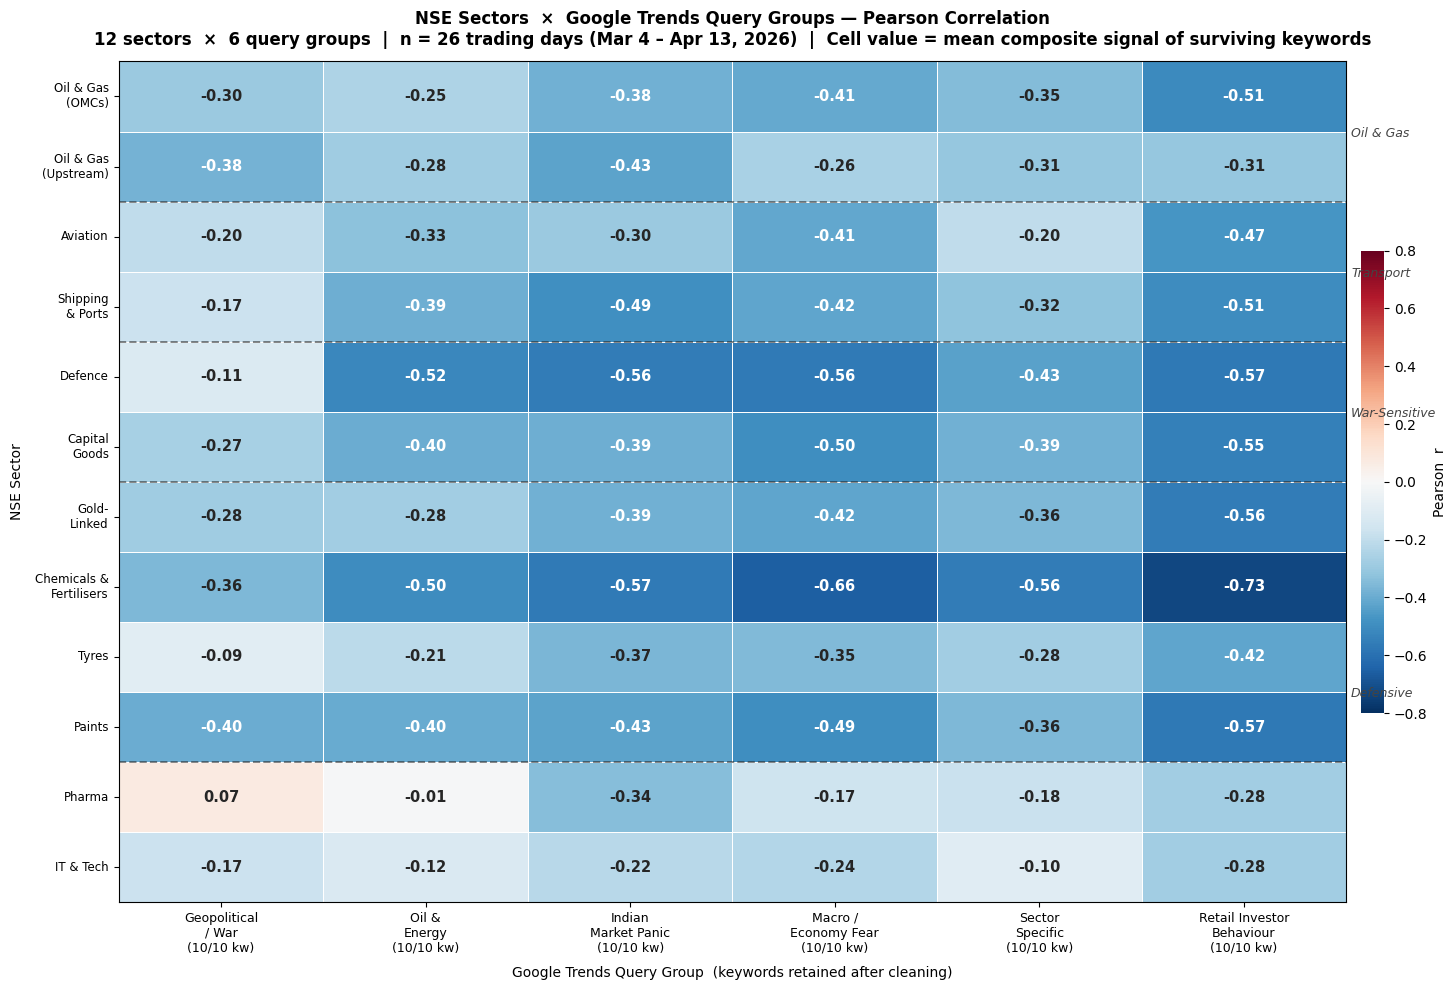

Saved: corr_groups_sectors.png


In [9]:
# ── Heatmap 3: Sectors (rows) × Keyword Groups (cols) — 12 × 6 ───────────────

# Column labels: group name + coverage count
col_labels = [
    f"{grp}\n({n}/{t} kw)"
    for grp, (n, t) in group_coverage.items()
]

# Row labels: short sector names (reuse SHORT_SEC from earlier cells)
row_labels = [SHORT_SEC.get(s, s) for s in CORR3.index]

CORR3_display = CORR3.copy()
CORR3_display.index   = row_labels
CORR3_display.columns = col_labels

# Annotation: value string or 'N/A' for the all-NaN group
annot_arr = pd.DataFrame(
    [
        [f"{v:.2f}" if not np.isnan(v) else "N/A" for v in row]
        for row in CORR3_display.values
    ],
    index=CORR3_display.index,
    columns=CORR3_display.columns,
)

nan_mask = CORR3_display.isna()

fig, ax = plt.subplots(figsize=(16, 10))

sns.heatmap(
    CORR3_display,
    cmap='RdBu_r',
    center=0,
    vmin=-0.8, vmax=0.8,
    linewidths=0.7,
    linecolor='white',
    annot=annot_arr,
    fmt='',
    annot_kws={'size': 10.5, 'weight': 'bold'},
    mask=nan_mask,
    ax=ax,
    cbar_kws={'label': 'Pearson  r', 'shrink': 0.55, 'pad': 0.01},
)

# Grey fill + N/A text for the all-NaN column (Indian Market Panic)
for col_idx, col in enumerate(CORR3_display.columns):
    if CORR3_display[col].isna().all():
        ax.add_patch(mpatches.Rectangle(
            (col_idx, 0), 1, len(CORR3_display),
            fill=True, color='#d8d8d8', zorder=2, alpha=0.9
        ))
        for row_idx in range(len(CORR3_display)):
            ax.text(
                col_idx + 0.5, row_idx + 0.5, 'N/A',
                ha='center', va='center',
                fontsize=9, color='#777777', style='italic', zorder=3
            )

# Horizontal dividers separating logical sector clusters
# Oil & Gas block (rows 0-1), then Aviation+Shipping (2-3), then rest
for row_b in [2, 4, 6, 10]:
    ax.axhline(row_b, color='#222222', linewidth=1.4, linestyle='--', alpha=0.55)

# Sector cluster labels on the right y-axis
cluster_labels = ['Oil & Gas', 'Transport', 'War-Sensitive', 'Defensive']
cluster_spans  = [(0, 2), (2, 4), (4, 6), (6, 12)]   # (start_row, end_row)

ax_r = ax.twinx()
ax_r.set_ylim(ax.get_ylim())
midpoints_r = [(s + e) / 2 for s, e in cluster_spans]
ax_r.set_yticks(midpoints_r)
ax_r.set_yticklabels(cluster_labels, fontsize=9, color='#444444', fontstyle='italic')
ax_r.tick_params(length=0)

ax.set_title(
    'NSE Sectors  ×  Google Trends Query Groups — Pearson Correlation\n'
    '12 sectors  ×  6 query groups  |  n = 26 trading days (Mar 4 – Apr 13, 2026)  |  '
    'Cell value = mean composite signal of surviving keywords',
    fontsize=12, pad=12, fontweight='bold'
)
ax.set_xlabel('Google Trends Query Group  (keywords retained after cleaning)', fontsize=10, labelpad=8)
ax.set_ylabel('NSE Sector', fontsize=10, labelpad=8)
ax.tick_params(axis='x', labelsize=9,   rotation=0)
ax.tick_params(axis='y', labelsize=8.5, rotation=0)

plt.tight_layout()
plt.savefig('corr_groups_sectors.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: corr_groups_sectors.png")